# Práctica: Comparación de Arquitecturas Convolucionales en CIFAR-10
**Objetivo:** Analizar el impacto de las conexiones residuales y la normalización por lotes (Batch Normalization) en el entrenamiento de redes neuronales profundas utilizando el dataset CIFAR-10.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
from tqdm.auto import tqdm

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de entrenamiento: {device}")

Dispositivo de entrenamiento: cuda


## 1. Configuración y Preprocesamiento de Datos
Se divide el conjunto de entrenamiento original (50,000 imágenes) en **Train** (40,000) y **Validation** (10,000). El conjunto de **Test** se mantiene con sus 10,000 imágenes estándar.

In [ ]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

dataset_completo = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_size = 40000
val_size = 10000
train_dataset, val_dataset = random_split(dataset_completo, [train_size, val_size], generator=torch.Generator().manual_seed(42))

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Tamaño Train: {len(train_dataset)} | Tamaño Val: {len(val_dataset)} | Tamaño Test: {len(test_dataset)}")

Tamaño Train: 40000 | Tamaño Val: 10000 | Tamaño Test: 10000


## 2. Definición de las Arquitecturas
A continuación, definimos los bloques internos para cada topología y una clase constructora genérica que respetará la misma macroestructura para los tres modelos.

In [ ]:

# Bloque A: Estándar (Sin residuales)
class StandardBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(StandardBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=True)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=True)
        self.relu2 = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu1(out)
        out = self.conv2(out)
        out = self.relu2(out)
        return out

# Bloque B: Residual
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=True)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=True)
        
        self.shortcut = nn.Sequential()
        # Si cambian las dimensiones (stride=2) o los canales, usamos proyección 1x1
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=True)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)
        out += identity # Suma de la ruta principal y la ruta corta
        out = self.relu(out)
        return out

# Bloque C: Residual + Batch Normalization
class ResidualBNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBNBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = self.relu(out)
        return out

class ConvNet(nn.Module):
    def __init__(self, block_type, num_classes=10):
        super(ConvNet, self).__init__()
        
        # Bloque inicial
        self.init_conv = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.init_relu = nn.ReLU(inplace=True)
        
        # Etapa 1: 2 bloques, 16 canales
        self.stage1 = nn.Sequential(
            block_type(16, 16, stride=1),
            block_type(16, 16, stride=1)
        )
        
        # Etapa 2: 2 bloques, 32 canales (el primer bloque usa stride=2)
        self.stage2 = nn.Sequential(
            block_type(16, 32, stride=2),
            block_type(32, 32, stride=1)
        )
        
        # Etapa 3: 2 bloques, 64 canales (el primer bloque usa stride=2)
        self.stage3 = nn.Sequential(
            block_type(32, 64, stride=2),
            block_type(64, 64, stride=1)
        )
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.init_conv(x)
        x = self.init_relu(x)
        
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

modelo_A = ConvNet(StandardBlock).to(device)
modelo_B = ConvNet(ResidualBlock).to(device)
modelo_C = ConvNet(ResidualBNBlock).to(device)

## 3 y 4. Ciclo de Entrenamiento y Registro de Métricas
Configuramos la función que se encargará del bucle de entrenamiento, registrando exactitud (Accuracy) y pérdida (Loss) tanto para Train como para Validation por cada época.

In [ ]:


def train_model(model, name, epochs=30, lr=0.001):
    print(f"\n{'-'*10} Iniciando entrenamiento de {name} {'-'*10}")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    pbar = tqdm(range(epochs), desc=f"Progreso {name}")
    
    for epoch in pbar:
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()
            
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = 100. * correct_train / total_train
        
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total_val += labels.size(0)
                correct_val += predicted.eq(labels).sum().item()
                
        epoch_val_loss = val_loss / total_val
        epoch_val_acc = 100. * correct_val / total_val
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        

        pbar.set_postfix({'Val Loss': f'{epoch_val_loss:.4f}'})
        pbar.write(f"Época [{epoch+1}/{epochs}] | "
                   f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}% | "
                   f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.2f}%")
              
    print(f" Entrenamiento de {name} completado.\n")
    return history

epochs = 30
hist_A = train_model(modelo_A, "Modelo A (Estándar)", epochs=epochs)
hist_B = train_model(modelo_B, "Modelo B (Residual)", epochs=epochs)
hist_C = train_model(modelo_C, "Modelo C (Residual + BN)", epochs=epochs)


---------- Iniciando entrenamiento de Modelo A (Estándar) ----------


Progreso Modelo A (Estándar):   0%|          | 0/30 [00:00<?, ?it/s]

Época [1/30] | Train Loss: 1.3671 - Train Acc: 49.56% | Val Loss: 1.3313 - Val Acc: 50.97%
Época [2/30] | Train Loss: 1.3039 - Train Acc: 52.15% | Val Loss: 1.2658 - Val Acc: 53.46%
Época [3/30] | Train Loss: 1.2338 - Train Acc: 55.04% | Val Loss: 1.2111 - Val Acc: 56.00%
Época [4/30] | Train Loss: 1.1936 - Train Acc: 56.78% | Val Loss: 1.1811 - Val Acc: 57.42%
Época [5/30] | Train Loss: 1.1448 - Train Acc: 58.72% | Val Loss: 1.1257 - Val Acc: 59.35%
Época [6/30] | Train Loss: 1.0937 - Train Acc: 60.95% | Val Loss: 1.0670 - Val Acc: 61.74%
Época [7/30] | Train Loss: 1.0406 - Train Acc: 62.71% | Val Loss: 1.0607 - Val Acc: 61.88%
Época [8/30] | Train Loss: 0.9991 - Train Acc: 64.28% | Val Loss: 1.0313 - Val Acc: 63.09%
Época [9/30] | Train Loss: 0.9551 - Train Acc: 65.91% | Val Loss: 1.0100 - Val Acc: 64.10%
Época [10/30] | Train Loss: 0.9136 - Train Acc: 67.59% | Val Loss: 0.9621 - Val Acc: 65.62%
Época [11/30] | Train Loss: 0.8854 - Train Acc: 68.46% | Val Loss: 0.9482 - Val Acc: 66.3

Progreso Modelo B (Residual):   0%|          | 0/30 [00:00<?, ?it/s]

Época [1/30] | Train Loss: 1.9024 - Train Acc: 27.18% | Val Loss: 1.6937 - Val Acc: 35.90%
Época [2/30] | Train Loss: 1.5941 - Train Acc: 40.24% | Val Loss: 1.5000 - Val Acc: 44.49%
Época [3/30] | Train Loss: 1.4508 - Train Acc: 46.35% | Val Loss: 1.4169 - Val Acc: 48.71%
Época [4/30] | Train Loss: 1.3406 - Train Acc: 50.95% | Val Loss: 1.3275 - Val Acc: 51.16%
Época [5/30] | Train Loss: 1.2421 - Train Acc: 54.53% | Val Loss: 1.2001 - Val Acc: 57.28%
Época [6/30] | Train Loss: 1.1586 - Train Acc: 57.78% | Val Loss: 1.1136 - Val Acc: 60.20%
Época [7/30] | Train Loss: 1.0711 - Train Acc: 61.22% | Val Loss: 1.0618 - Val Acc: 62.13%
Época [8/30] | Train Loss: 1.0290 - Train Acc: 62.93% | Val Loss: 1.0056 - Val Acc: 63.64%
Época [9/30] | Train Loss: 0.9546 - Train Acc: 65.69% | Val Loss: 1.0326 - Val Acc: 62.71%
Época [10/30] | Train Loss: 0.8969 - Train Acc: 68.03% | Val Loss: 0.8926 - Val Acc: 68.01%
Época [11/30] | Train Loss: 0.8628 - Train Acc: 69.23% | Val Loss: 0.9094 - Val Acc: 68.1

Progreso Modelo C (Residual + BN):   0%|          | 0/30 [00:00<?, ?it/s]

Época [1/30] | Train Loss: 1.4866 - Train Acc: 44.95% | Val Loss: 1.5865 - Val Acc: 44.30%
Época [2/30] | Train Loss: 1.0798 - Train Acc: 60.84% | Val Loss: 1.3469 - Val Acc: 52.39%
Época [3/30] | Train Loss: 0.9017 - Train Acc: 67.86% | Val Loss: 0.9425 - Val Acc: 65.98%
Época [4/30] | Train Loss: 0.7860 - Train Acc: 72.39% | Val Loss: 0.9628 - Val Acc: 65.71%
Época [5/30] | Train Loss: 0.6934 - Train Acc: 75.56% | Val Loss: 0.9229 - Val Acc: 68.39%
Época [6/30] | Train Loss: 0.6259 - Train Acc: 78.13% | Val Loss: 0.8687 - Val Acc: 69.39%
Época [7/30] | Train Loss: 0.5670 - Train Acc: 80.13% | Val Loss: 0.8539 - Val Acc: 71.25%
Época [8/30] | Train Loss: 0.5180 - Train Acc: 81.98% | Val Loss: 0.6900 - Val Acc: 76.21%
Época [9/30] | Train Loss: 0.4699 - Train Acc: 83.74% | Val Loss: 0.7696 - Val Acc: 73.88%
Época [10/30] | Train Loss: 0.4286 - Train Acc: 85.02% | Val Loss: 0.7656 - Val Acc: 74.23%
Época [11/30] | Train Loss: 0.3757 - Train Acc: 87.10% | Val Loss: 0.8365 - Val Acc: 72.7

## 5. Evaluación Final (Test)
Una vez completadas las 30 épocas, evaluamos el rendimiento final en el conjunto de prueba (Test) que el modelo nunca ha visto durante el entrenamiento o la validación.

In [ ]:
def evaluate_on_test(model):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    test_loss = 0.0
    correct_test = 0
    total_test = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_test += labels.size(0)
            correct_test += predicted.eq(labels).sum().item()
            
    final_loss = test_loss / total_test
    final_acc = 100. * correct_test / total_test
    return final_loss, final_acc

# Evaluar modelos
loss_A, acc_A = evaluate_on_test(modelo_A)
loss_B, acc_B = evaluate_on_test(modelo_B)
loss_C, acc_C = evaluate_on_test(modelo_C)

# DataFrame comparativo
resultados_test = pd.DataFrame({
    'Modelo': ['A (Estándar)', 'B (Residual)', 'C (Residual + BN)'],
    'Test Loss': [loss_A, loss_B, loss_C],
    'Test Accuracy (%)': [acc_A, acc_B, acc_C]
})

print("\n--- Resultados Finales en Conjunto de Test ---")
display(resultados_test)


--- Resultados Finales en Conjunto de Test ---


,Modelo,Test Loss,Test Accuracy (%)
0,A (Estándar),1.032207,69.37
1,B (Residual),0.737225,76.20
2,C (Residual + BN),1.145779,76.39


## 6. Gráficas Comparativas y Curvas de Aprendizaje
Generación de las curvas de Pérdida (Loss) y Exactitud (Accuracy) de Validación para observar el impacto estructural en el aprendizaje.

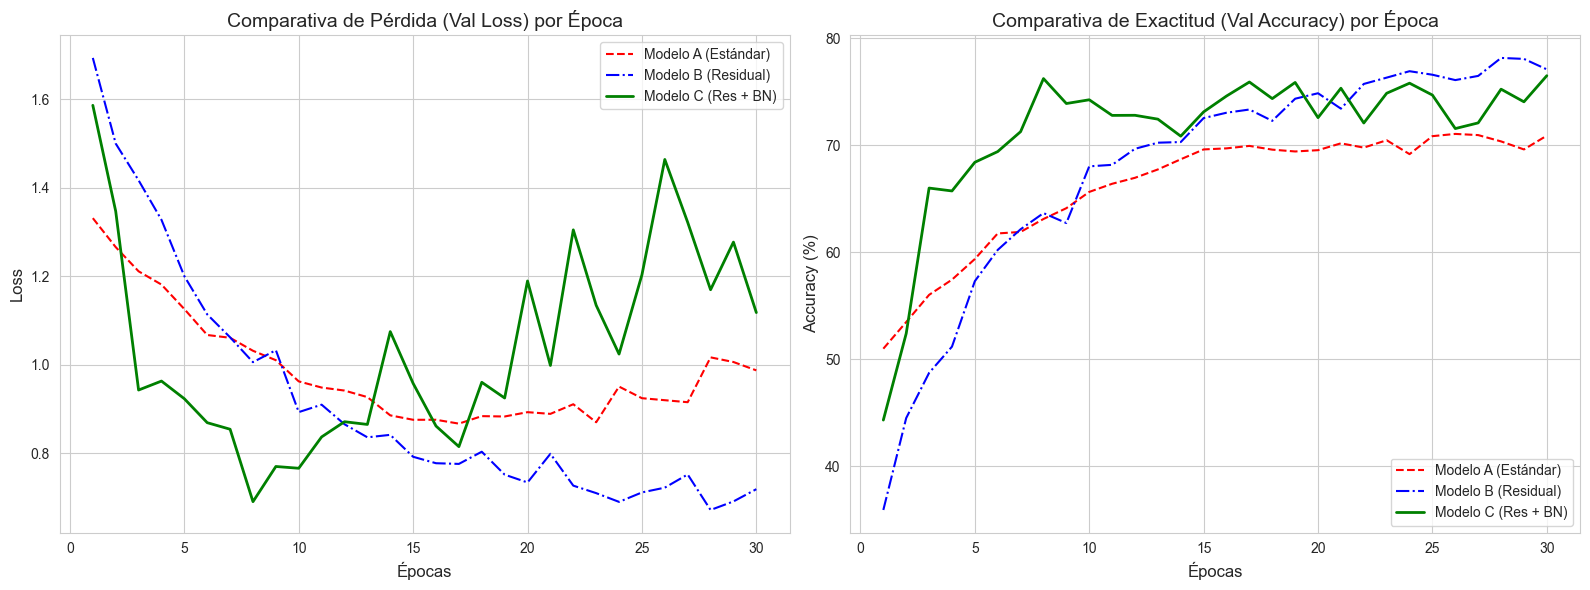

In [ ]:
sns.set_style("whitegrid")
epocas_rango = range(1, epochs + 1)

plt.figure(figsize=(16, 6))

# Gráfica 1: Comparativa de Pérdida en Validación 
plt.subplot(1, 2, 1)
plt.plot(epocas_rango, hist_A['val_loss'], label='Modelo A (Estándar)', color='red', linestyle='--')
plt.plot(epocas_rango, hist_B['val_loss'], label='Modelo B (Residual)', color='blue', linestyle='-.')
plt.plot(epocas_rango, hist_C['val_loss'], label='Modelo C (Res + BN)', color='green', linewidth=2)
plt.title('Comparativa de Pérdida (Val Loss) por Época', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()

# Gráfica 2: Comparativa de Exactitud en Validación 
plt.subplot(1, 2, 2)
plt.plot(epocas_rango, hist_A['val_acc'], label='Modelo A (Estándar)', color='red', linestyle='--')
plt.plot(epocas_rango, hist_B['val_acc'], label='Modelo B (Residual)', color='blue', linestyle='-.')
plt.plot(epocas_rango, hist_C['val_acc'], label='Modelo C (Res + BN)', color='green', linewidth=2)
plt.title('Comparativa de Exactitud (Val Accuracy) por Época', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

# Experimento 2: Mitigación del Sobreajuste mediante Regularización y Aumento de Datos

En esta sección se repite el entrenamiento de las tres topologías (A, B y C) aplicando tres mejoras simultáneas orientadas a mitigar el sobreajuste y mejorar la capacidad de generalización en el conjunto de validación:
1. **Aumento de Datos (Data Augmentation):** Inversiones horizontales y recortes aleatorios en el conjunto de entrenamiento.
2. **Decaimiento de Pesos (Weight Decay):** Regularización L2 ($1\times10^{-4}$) en el optimizador Adam para penalizar pesos excesivamente grandes.
3. **Planificador de LR (ReduceLROnPlateau):** Reducción dinámica de la tasa de aprendizaje por un factor de 10 si el `Val Loss` se estanca durante 3 épocas.

In [ ]:

# Transformación con Aumento de Datos para el entrenamiento
train_transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Transformación estándar para validación y prueba (sin alteraciones)
test_transform_std = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])


dataset_train_pure = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=train_transform_aug)
dataset_val_pure = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=test_transform_std)

# Conservamos exactamente los mismos índices del experimento 1 para mantener la consistencia
train_dataset_aug = torch.utils.data.Subset(dataset_train_pure, train_dataset.indices)
val_dataset_aug = torch.utils.data.Subset(dataset_val_pure, val_dataset.indices)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader_aug = DataLoader(val_dataset_aug, batch_size=batch_size, shuffle=False, num_workers=2)

print("DataLoaders del Experimento 2 configurados con los mismos índices bases.")

DataLoaders del Experimento 2 configurados con los mismos índices bases.


## 2. Ciclo de Entrenamiento Avanzado con Regularización y Scheduler

Definimos una nueva función de entrenamiento que incorpora el parámetro `weight_decay` en el optimizador y administra el objeto `ReduceLROnPlateau`. Mapearemos el valor actual del Learning Rate en cada época para monitorear el comportamiento del planificador.

In [ ]:

def train_model_enhanced(model, name, epochs=30, lr=0.001, weight_decay=1e-4):
    print(f"\n{'-'*10} Iniciando Experimento 2: {name} {'-'*10}")
    criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Planificador de Tasa de Aprendizaje (LR Scheduler)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
    pbar = tqdm(range(epochs), desc=f"Progreso {name}")
    
    for epoch in pbar:
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)
      
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for inputs, labels in train_loader_aug: 
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()
            
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = 100. * correct_train / total_train
        
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader_aug:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total_val += labels.size(0)
                correct_val += predicted.eq(labels).sum().item()
                
        epoch_val_loss = val_loss / total_val
        epoch_val_acc = 100. * correct_val / total_val
        
        # Actualizar planificador
        scheduler.step(epoch_val_loss)
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        
        pbar.set_postfix({'Val Loss': f'{epoch_val_loss:.4f}', 'LR': f'{current_lr:.5f}'})
        
        pbar.write(f"Época [{epoch+1}/{epochs}] | "
                   f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}% | "
                   f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.2f}% | "
                   f"LR: {current_lr:.6f}")
              
    print(f"Experimento 2 para {name} completado.\n")
    return history

## 3. Inicialización y Ejecución de los Nuevos Modelos mejorados

Instanciamos tres nuevas redes independientes para evitar alterar los pesos entrenados en la primera fase de la práctica.

In [ ]:

modelo_A_aug = ConvNet(StandardBlock).to(device)
modelo_B_aug = ConvNet(ResidualBlock).to(device)
modelo_C_aug = ConvNet(ResidualBNBlock).to(device)
epochs = 30

# weight_decay=0.0 al Modelo A
hist_A_aug = train_model_enhanced(modelo_A_aug, "Modelo A ( Data Augmentation)", epochs=epochs, weight_decay=0)

hist_B_aug = train_model_enhanced(modelo_B_aug, "Modelo B (Residual + Reg)", epochs=epochs)
hist_C_aug = train_model_enhanced(modelo_C_aug, "Modelo C (Residual + BN + Reg)", epochs=epochs)


---------- Iniciando Experimento 2: Modelo A ( Data Augmentation) ----------


Progreso Modelo A ( Data Augmentation):   0%|          | 0/30 [00:00<?, ?it/s]

Época [1/30] | Train Loss: 2.0878 - Train Acc: 18.86% | Val Loss: 1.9202 - Val Acc: 23.15% | LR: 0.001000
Época [2/30] | Train Loss: 1.8688 - Train Acc: 25.81% | Val Loss: 1.7933 - Val Acc: 29.18% | LR: 0.001000
Época [3/30] | Train Loss: 1.7627 - Train Acc: 31.47% | Val Loss: 1.6516 - Val Acc: 36.83% | LR: 0.001000
Época [4/30] | Train Loss: 1.6523 - Train Acc: 36.58% | Val Loss: 1.6014 - Val Acc: 39.88% | LR: 0.001000
Época [5/30] | Train Loss: 1.5730 - Train Acc: 40.63% | Val Loss: 1.5291 - Val Acc: 42.38% | LR: 0.001000
Época [6/30] | Train Loss: 1.5073 - Train Acc: 43.86% | Val Loss: 1.4641 - Val Acc: 45.76% | LR: 0.001000
Época [7/30] | Train Loss: 1.4250 - Train Acc: 47.49% | Val Loss: 1.3702 - Val Acc: 49.54% | LR: 0.001000
Época [8/30] | Train Loss: 1.3502 - Train Acc: 50.55% | Val Loss: 1.2737 - Val Acc: 53.52% | LR: 0.001000
Época [9/30] | Train Loss: 1.2811 - Train Acc: 53.32% | Val Loss: 1.2790 - Val Acc: 54.30% | LR: 0.001000
Época [10/30] | Train Loss: 1.2291 - Train Acc

Progreso Modelo B (Residual + Reg):   0%|          | 0/30 [00:00<?, ?it/s]

Época [1/30] | Train Loss: 1.9805 - Train Acc: 24.23% | Val Loss: 1.7217 - Val Acc: 33.60% | LR: 0.001000
Época [2/30] | Train Loss: 1.6818 - Train Acc: 36.33% | Val Loss: 1.5936 - Val Acc: 39.98% | LR: 0.001000
Época [3/30] | Train Loss: 1.5190 - Train Acc: 43.15% | Val Loss: 1.4728 - Val Acc: 44.12% | LR: 0.001000
Época [4/30] | Train Loss: 1.4195 - Train Acc: 47.59% | Val Loss: 1.3462 - Val Acc: 51.78% | LR: 0.001000
Época [5/30] | Train Loss: 1.3077 - Train Acc: 52.10% | Val Loss: 1.2323 - Val Acc: 55.24% | LR: 0.001000
Época [6/30] | Train Loss: 1.2255 - Train Acc: 55.12% | Val Loss: 1.2427 - Val Acc: 56.19% | LR: 0.001000
Época [7/30] | Train Loss: 1.1664 - Train Acc: 57.98% | Val Loss: 1.2396 - Val Acc: 55.90% | LR: 0.001000
Época [8/30] | Train Loss: 1.1145 - Train Acc: 60.05% | Val Loss: 1.1428 - Val Acc: 60.40% | LR: 0.001000
Época [9/30] | Train Loss: 1.0646 - Train Acc: 62.03% | Val Loss: 1.0777 - Val Acc: 61.71% | LR: 0.001000
Época [10/30] | Train Loss: 1.0152 - Train Acc

Progreso Modelo C (Residual + BN + Reg):   0%|          | 0/30 [00:00<?, ?it/s]

Época [1/30] | Train Loss: 1.5970 - Train Acc: 41.02% | Val Loss: 1.3110 - Val Acc: 52.12% | LR: 0.001000
Época [2/30] | Train Loss: 1.2039 - Train Acc: 56.37% | Val Loss: 1.1779 - Val Acc: 57.23% | LR: 0.001000
Época [3/30] | Train Loss: 1.0241 - Train Acc: 63.48% | Val Loss: 1.3440 - Val Acc: 55.74% | LR: 0.001000
Época [4/30] | Train Loss: 0.9246 - Train Acc: 66.89% | Val Loss: 0.9512 - Val Acc: 66.93% | LR: 0.001000
Época [5/30] | Train Loss: 0.8432 - Train Acc: 70.13% | Val Loss: 1.1902 - Val Acc: 61.55% | LR: 0.001000
Época [6/30] | Train Loss: 0.7817 - Train Acc: 72.70% | Val Loss: 0.7569 - Val Acc: 73.17% | LR: 0.001000
Época [7/30] | Train Loss: 0.7192 - Train Acc: 74.80% | Val Loss: 0.7446 - Val Acc: 74.06% | LR: 0.001000
Época [8/30] | Train Loss: 0.6794 - Train Acc: 76.33% | Val Loss: 0.8680 - Val Acc: 70.95% | LR: 0.001000
Época [9/30] | Train Loss: 0.6399 - Train Acc: 77.57% | Val Loss: 0.9258 - Val Acc: 70.27% | LR: 0.001000
Época [10/30] | Train Loss: 0.6102 - Train Acc

## 4. Evaluación Final en el Conjunto de Test (Experimento 2)

Se extraen las métricas finales utilizando el loader de pruebas original (`test_loader`), desplegando los resultados en una estructura matricial comparativa de Pandas.

In [ ]:
def evaluate_on_test(model):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    test_loss = 0.0
    correct_test = 0
    total_test = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_test += labels.size(0)
            correct_test += predicted.eq(labels).sum().item()
            
    final_loss = test_loss / total_test
    final_acc = 100. * correct_test / total_test
    return final_loss, final_acc

loss_A, acc_A = evaluate_on_test(modelo_A)
loss_B, acc_B = evaluate_on_test(modelo_B)
loss_C, acc_C = evaluate_on_test(modelo_C)

# Crear DataFrame comparativo
resultados_test = pd.DataFrame({
    'Modelo': ['A (Estándar)', 'B (Residual)', 'C (Residual + BN)'],
    'Test Loss': [loss_A, loss_B, loss_C],
    'Test Accuracy (%)': [acc_A, acc_B, acc_C]
})

loss_A_aug, acc_A_aug = evaluate_on_test(modelo_A_aug)
loss_B_aug, acc_B_aug = evaluate_on_test(modelo_B_aug)
loss_C_aug, acc_C_aug = evaluate_on_test(modelo_C_aug)

# Construcción de la tabla de resultados finales de la segunda fase
resultados_test_exp2 = pd.DataFrame({
    'Modelo (Experimento 2)': ['A (Estándar + Reg)', 'B (Residual + Reg)', 'C (Residual + BN + Reg)'],
    'Test Loss': [loss_A_aug, loss_B_aug, loss_C_aug],
    'Test Accuracy (%)': [acc_A_aug, acc_B_aug, acc_C_aug]
})

print("\n--- Resultados Finales del Experimento 2 en Test ---")
display(resultados_test_exp2)


--- Resultados Finales del Experimento 2 en Test ---


,Modelo (Experimento 2),Test Loss,Test Accuracy (%)
0,A (Estándar + Reg),0.811071,71.95
1,B (Residual + Reg),0.689198,75.97
2,C (Residual + BN + Reg),0.445540,85.02


## 5. Curvas de Aprendizaje Comparativas (Experimento 2)

Graficamos las nuevas trayectorias de `Val Loss` y `Val Accuracy`. Al analizar visualmente estas curvas, se debería observar una convergencia mucho más suave, una reducción drástica del desfase entre las métricas de Train y Validación, y una clara ventaja final en la tasa de acierto del Modelo C gracias al soporte conjunto del Batch Normalization y los esquemas de regularización.

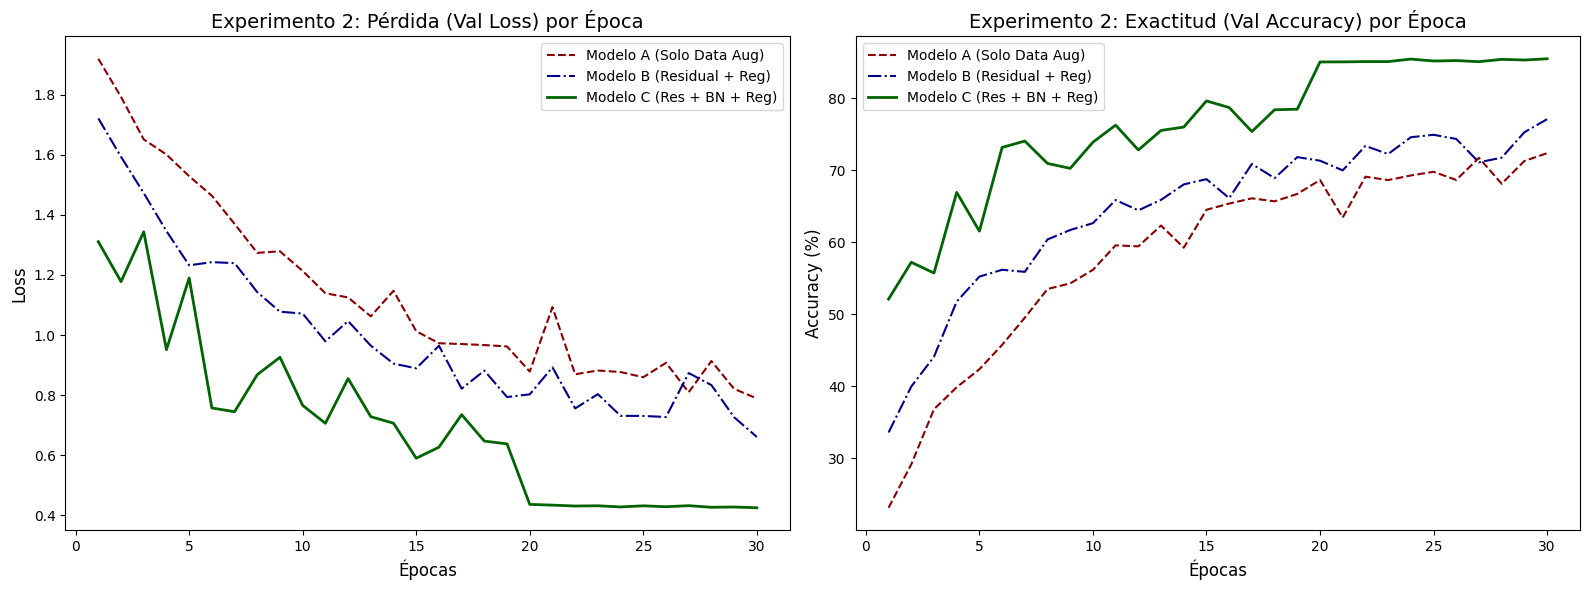

In [ ]:

epochs = 30 
epocas_rango = range(1, epochs + 1)

plt.figure(figsize=(16, 6))

# Gráfica 1: Pérdida en Validación - Experimento 2
plt.subplot(1, 2, 1)
plt.plot(epocas_rango, hist_A_aug['val_loss'], label='Modelo A (Solo Data Aug)', color='darkred', linestyle='--')
plt.plot(epocas_rango, hist_B_aug['val_loss'], label='Modelo B (Residual + Reg)', color='darkblue', linestyle='-.')
plt.plot(epocas_rango, hist_C_aug['val_loss'], label='Modelo C (Res + BN + Reg)', color='darkgreen', linewidth=2)
plt.title('Experimento 2: Pérdida (Val Loss) por Época', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()

# Gráfica 2: Exactitud en Validación - Experimento 2
plt.subplot(1, 2, 2)
plt.plot(epocas_rango, hist_A_aug['val_acc'], label='Modelo A (Solo Data Aug)', color='darkred', linestyle='--')
plt.plot(epocas_rango, hist_B_aug['val_acc'], label='Modelo B (Residual + Reg)', color='darkblue', linestyle='-.')
plt.plot(epocas_rango, hist_C_aug['val_acc'], label='Modelo C (Res + BN + Reg)', color='darkgreen', linewidth=2)
plt.title('Experimento 2: Exactitud (Val Accuracy) por Época', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
def contar_parametros(model):
    # Suma el número de elementos (numel) de cada parámetro si requiere gradiente
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Imprimir los parámetros de las redes del primer experimento
print("=== PARÁMETROS ENTRENABLES POR ARQUITECTURA ===")
print(f"Modelo A (Estándar):      {contar_parametros(modelo_A):,}")
print(f"Modelo B (Residual):      {contar_parametros(modelo_B):,}")
print(f"Modelo C (Residual + BN): {contar_parametros(modelo_C):,}")

=== PARÁMETROS ENTRENABLES POR ARQUITECTURA ===
Modelo A (Estándar):      172,042
Modelo B (Residual):      174,698
Modelo C (Residual + BN): 175,242
